# Vol 28 — Credit Desk — CDS, CDO, Correlation, CreditMetrics

**問い:** Hull Ch.24–25 の印刷された数値例を、検証済みコードで一つ残らず再現できるか。

> **核心** — 複雑なモデルは必ず単純baselineとhard checkに並べる。<br>
> **直感** — 平均誤差だけでは、尾部・裁定・cash-flow破綻を隠せる。<br>
> **実務** — 再現可能なartifactと明示的な失敗条件をmodel risk管理の単位にする。

## モデルladderと責務

vol.09 が説明文で済ませた節を節単位で埋める。債券価格と CDS 気配からの区分定数ハザード（Ex 24.1/24.2）、Table 25.2–25.4 の CDS レッグと MTM、Ex 25.1 の固定クーポン価格、Black 型 CDS オプション、Gauss–Hermite 求積による合成 CDO（Ex 25.2）と k-th-to-default（Ex 25.3）、Table 25.6 の iTraxx 気配から Table 25.8 のコンパウンド/ベース相関、double-t コピュラと不均質再帰（§25.11）、Table 24.4 の CreditMetrics 閾値と相関付き格付推移 MC、§24.7 のネッティング・担保・式 (24.5)。すべて Hull の離散化（期末払い・期中デフォルト）に合わせ、印刷値に ±許容で固定する。

## Artifact契約とdata policy

このnotebookはcommitted JSON/NPZだけを読み、学習・download・GPU検出を行わない。

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import matplotlib.pyplot as plt

reference = Path('reference')
manifest = json.loads((reference / 'metrics.json').read_text(encoding='utf-8'))
artifact = reference / 'credit_scenarios.npz'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
assert manifest['schema_version'] == 1 and manifest['volume'] == 28
assert manifest['data_policy'] == 'synthetic-offline'
assert manifest['companions'][artifact.name] == digest
archive = np.load(artifact, allow_pickle=False)
schema = manifest['companion_schemas'][artifact.name]
assert set(schema) == set(archive.files)
for name in archive.files:
    assert schema[name]['shape'] == list(archive[name].shape)
    assert schema[name]['dtype'] == str(archive[name].dtype)
    assert schema[name]['unit']
artifact_data = {name: archive[name] for name in archive.files}
archive.close()
data = dict(artifact_data)
print(f"schema={manifest['schema_version']} volume={manifest['volume']} digest={digest[:16]} arrays={len(artifact_data)}")

schema=1 volume=28 digest=9c50708c8ea033c0 arrays=86


## 指標の要約

指標は同じsynthetic fixture・単位・seedで比較する。

In [2]:
for key, value in manifest['metrics'].items():
    print(f'{key}: {value}')

base_correlation_max_reprice_error: 3.737895409861025e-15
binary_cds_spread_bp: 205.00429358998645
bond_bootstrap_hazard_1: 0.024575329948416012
bond_bootstrap_hazard_2: 0.03475777894122982
bond_bootstrap_hazard_3: 0.037351228053560705
cdo_index_hazard: 0.008296995340469394
cdo_mezz_accrual: 0.01869664988180446
cdo_mezz_annuity: 4.28464661505203
cdo_mezz_protection: 0.14957319905443567
cdo_mezz_spread_bp: 347.5744086539548
cdo_rate: 0.035
cdo_rho: 0.15
cds_bootstrap_max_reprice_error: 4.388850394221322e-16
cds_hazard: 0.02
cds_implied_hazard_100bp: 0.016258868561856883
cds_mtm_seller_150bp: 0.011109406541533029
cds_par_spread_bp: 123.00257615399185
cds_protection_pv: 0.050615408045779915
cds_rate: 0.05
cds_risky_duration: 4.114987639154196
credit_var_correlated: 6.599999999999999
credit_var_independent: 3.0
creditmetrics_bbb_default_threshold: 2.9290497489376195
creditmetrics_rho: 0.2
cva_general_equivalent: 0.24458895909902348
cva_no_default_value: 7.0
cva_rate: 0.05
cva_special_case:

## Acceptance scope

この判定はintegrationと再現性だけを対象とし、市場適合・予測力・production readinessを承認しない。

In [3]:
assert manifest['acceptance']['scope'] == 'integration_and_reproducibility'
assert manifest['acceptance']['model_performance_approved'] is False
assert manifest['acceptance']['passed'] is True
for check in manifest['acceptance']['checks']:
    print(('PASS' if check['passed'] else 'FAIL'), check['name'], check['observed'], check['criterion'])

PASS cds_par_spread_hull_pin 123.00257615399185 Σpayoff/(Σpayment+Σaccrual) within 0.5 bp of Hull's 123 bp and 1e-9 bp of the stored metric
PASS cds_mtm_identity 0.011109406541533029 D·0.015 − protection equals the stored metric and the grid value (1e-10) and Hull's 0.0111 (1e-4)
PASS cds_bootstrap_round_trip 4.388850394221322e-16 max |repriced − market| <= 1e-10
PASS bond_bootstrap_hull_pin 0.0019938056124146897 hazards within 0.0002 of 2.46/3.48/3.74% and loss PVs within 0.01 of 1.50/3.53/5.61
PASS fixed_coupon_price_identity 100.2705504281483 100 − 100·D·(s−c) equals the stored price (1e-10) and Hull's 100.27 (0.01)
PASS cds_option_parity 1.3877787807814457e-17 max |payer − receiver − A(F−K)| <= 1e-10
PASS cdo_mezz_spread_hull_pin 347.5744086539548 re-integrated C/(A+B) within 1 bp of Hull's 348 bp, 1e-9 bp of the stored metric, and 1e-6 bp of an independent numpy repricing; A/B/C within 0.002 of 4.2846/0.0187/0.1496
PASS expected_principal_monotone 1.1102230246251565e-16 E_j(F) non

## 債券価格ブートストラップ vs Hull Ex 24.2

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20661 (\N{CJK UNIFIED IDEOGRAPH-50B5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21048 (\N{CJK UNIFIED IDEOGRAPH-5238}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683

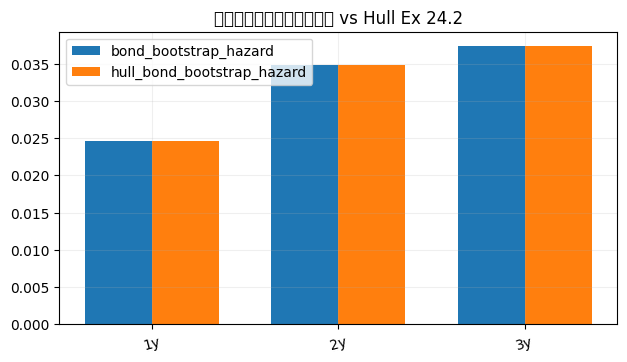

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("債券価格ブートストラップ vs Hull Ex 24.2")
x = np.arange(len(data["bond_maturity_label"]))
ax.bar(x - .18, data["bond_bootstrap_hazard"], width=.36, label="bond_bootstrap_hazard")
ax.bar(x + .18, data["hull_bond_bootstrap_hazard"], width=.36, label="hull_bond_bootstrap_hazard")
ax.set_xticks(x, data["bond_maturity_label"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## CDS レッグの年別 PV（Table 25.3 vs 25.4）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12464 (\N{KATAKANA LETTER GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) D

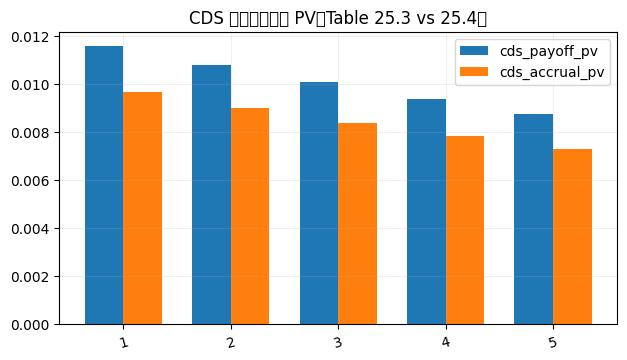

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("CDS レッグの年別 PV（Table 25.3 vs 25.4）")
x = np.arange(len(data["cds_year_label"]))
ax.bar(x - .18, data["cds_payoff_pv"], width=.36, label="cds_payoff_pv")
ax.bar(x + .18, data["cds_accrual_pv"], width=.36, label="cds_accrual_pv")
ax.set_xticks(x, data["cds_year_label"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## 契約スプレッド別の売り手 MTM（150bp で 0.0111）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22865 (\N{CJK UNIFIED IDEOGRAPH-5951}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32004 (\N{CJK UNIFIED IDEOGRAPH-7D04}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from

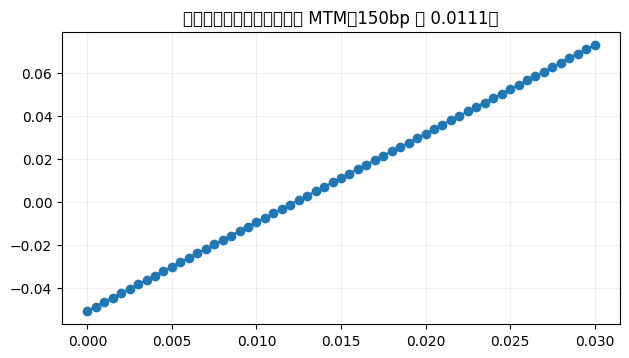

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("契約スプレッド別の売り手 MTM（150bp で 0.0111）")
ax.plot(data["cds_contract_spread_grid"], data["cds_mtm_seller"], marker="o")
ax.grid(alpha=.2)
plt.show()

## 固定クーポン 40bp のアップフロント価格 vs 気配（Ex 25.1）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22266 (\N{CJK UNIFIED IDEOGRAPH-56FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND

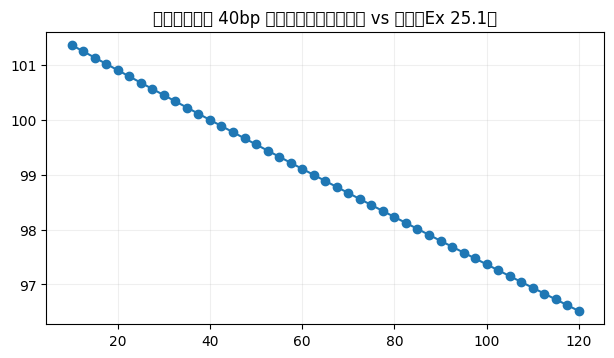

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("固定クーポン 40bp のアップフロント価格 vs 気配（Ex 25.1）")
ax.plot(data["index_quote_grid"], data["fixed_coupon_price_grid"], marker="o")
ax.grid(alpha=.2)
plt.show()

## CDS オプション payer / receiver（Black 型）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12458 (\N{KATAKANA LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12519 (\N{KATAKANA LETTER SMALL YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from fo

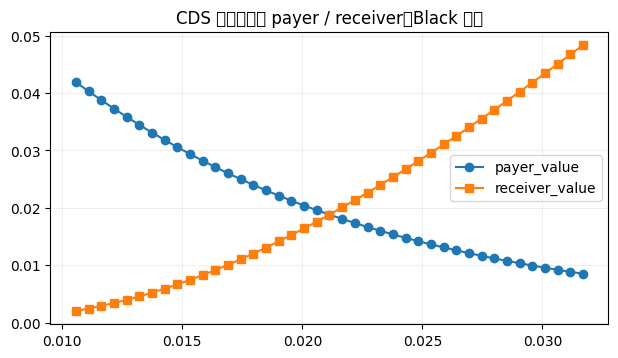

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("CDS オプション payer / receiver（Black 型）")
ax.plot(data["option_strike_grid"], data["payer_value"], marker="o", label="payer_value")
ax.plot(data["option_strike_grid"], data["receiver_value"], marker="s", label="receiver_value")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## メザニン期待元本 E_j(F_k)（Table 25.7）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12513 (\N{KATAKANA LETTER ME}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12470 (\N{KATAKANA LETTER ZA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12491 (\N{KATAKANA LETTER NI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s)

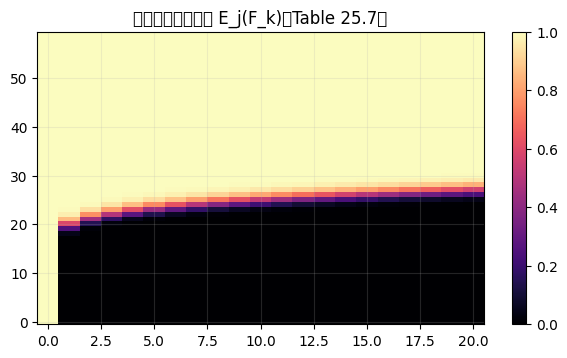

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("メザニン期待元本 E_j(F_k)（Table 25.7）")
im = ax.imshow(data["tranche_expected_principal"], aspect="auto", origin="lower", cmap="magma")
fig.colorbar(im, ax=ax)
ax.grid(alpha=.2)
plt.show()

## 標準トランシェのブレークイーブンスプレッド vs ρ

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28310 (\N{CJK UNIFIED IDEOGRAPH-6E96}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12455 (\N{KATAKANA LETTER SMALL E}) missing

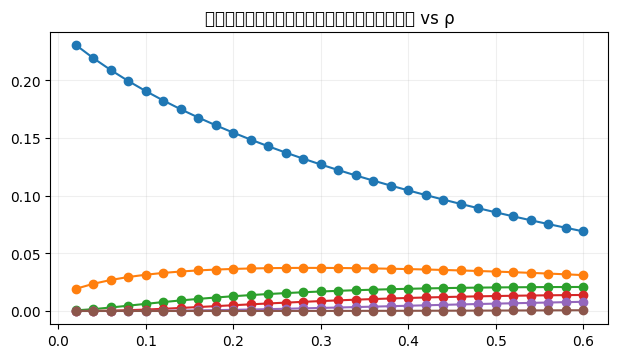

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("標準トランシェのブレークイーブンスプレッド vs ρ")
ax.plot(data["rho_grid"], data["tranche_spread_vs_rho"], marker="o")
ax.grid(alpha=.2)
plt.show()

## k-th-to-default スプレッド（Ex 25.3 は k=3）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12399 (\N{HIRAGANA LETTER HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


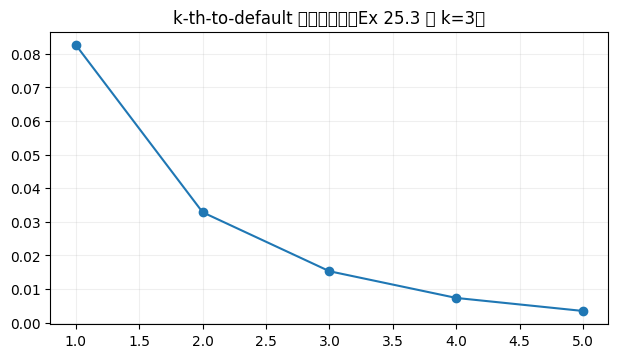

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("k-th-to-default スプレッド（Ex 25.3 は k=3）")
ax.plot(data["kth_order"], data["kth_spread"], marker="o")
ax.grid(alpha=.2)
plt.show()

## Table 25.8：コンパウンド vs ベース相関

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12467 (\N{KATAKANA LETTER KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12505 (\N{KATAKANA LETTER BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) 

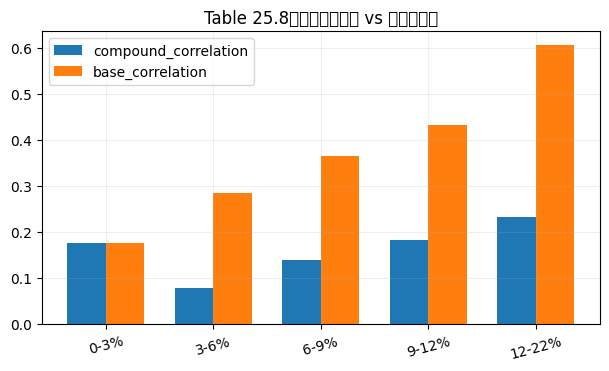

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("Table 25.8：コンパウンド vs ベース相関")
x = np.arange(len(data["market_tranche_label"]))
ax.bar(x - .18, data["compound_correlation"], width=.36, label="compound_correlation")
ax.bar(x + .18, data["base_correlation"], width=.36, label="base_correlation")
ax.set_xticks(x, data["market_tranche_label"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## 0–X% 期待損失 PV（Figure 25.3）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24453 (\N{CJK UNIFIED IDEOGRAPH-5F85}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25613 (\N{CJK UNIFIED IDEOGRAPH-640D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESI

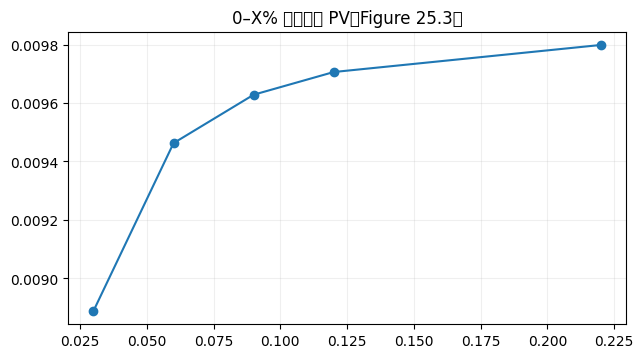

In [13]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("0–X% 期待損失 PV（Figure 25.3）")
ax.plot(data["el_curve_x"], data["el_curve_value"], marker="o")
ax.grid(alpha=.2)
plt.show()

## double-t コピュラのメザニンスプレッド vs ν

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12500 (\N{KATAKANA LETTER PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12517 (\N{KATAKANA LETTER SMALL YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) D

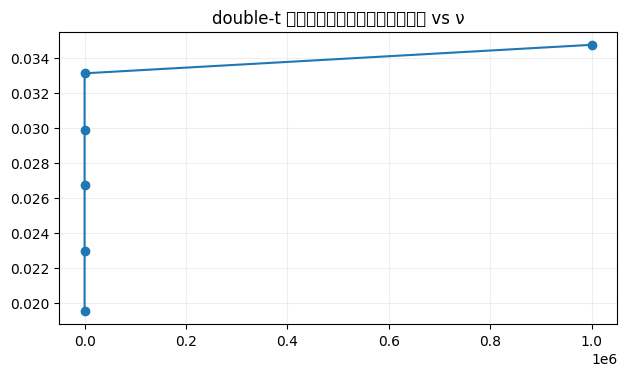

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("double-t コピュラのメザニンスプレッド vs ν")
ax.plot(data["double_t_nu_grid"], data["double_t_spread"], marker="o")
ax.grid(alpha=.2)
plt.show()

## CreditMetrics 閾値：AAA vs BBB（Table 24.4、生存格付間の 6 境界）

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38334 (\N{CJK UNIFIED IDEOGRAPH-95BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12289 (\N{IDEOGRAPHIC COMMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missi

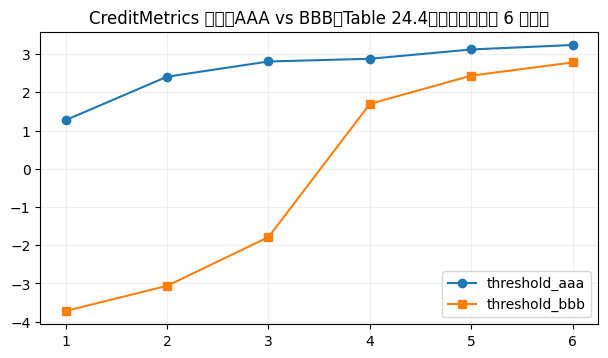

In [15]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("CreditMetrics 閾値：AAA vs BBB（Table 24.4、生存格付間の 6 境界）")
ax.plot(data["threshold_index"], data["threshold_aaa"], marker="o", label="threshold_aaa")
ax.plot(data["threshold_index"], data["threshold_bbb"], marker="s", label="threshold_bbb")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## 信用損失分布：独立 vs ρ=0.2

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E0

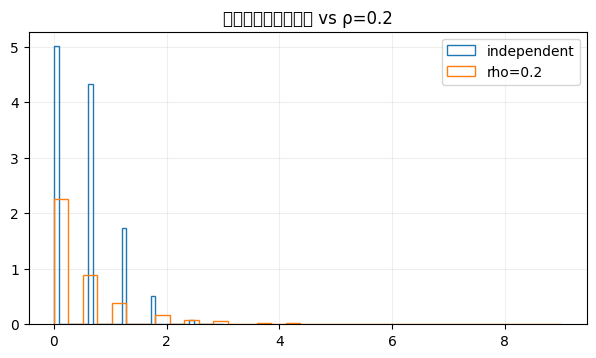

In [16]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("信用損失分布：独立 vs ρ=0.2")
for i, label in enumerate(data["credit_loss_names"]):
    ax.hist(data["credit_loss_by_case"][i], bins=35, density=True, histtype="step", label=str(label))
ax.legend()
ax.grid(alpha=.2)
plt.show()

## 担保付きエクスポージャ：Ex 24.4 の 4 ケース

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25285 (\N{CJK UNIFIED IDEOGRAPH-62C5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20445 (\N{CJK UNIFIED IDEOGRAPH-4FDD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20184 (\N{CJK UNIFIED IDEOGRAPH-4ED8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12365 (\N{HIRAGANA LETTER KI}) miss

/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kazumasa/projects/.claude/worktrees/johnhull-vol28-credit-desk/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12465 (\N{KATAKANA LETTER KE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


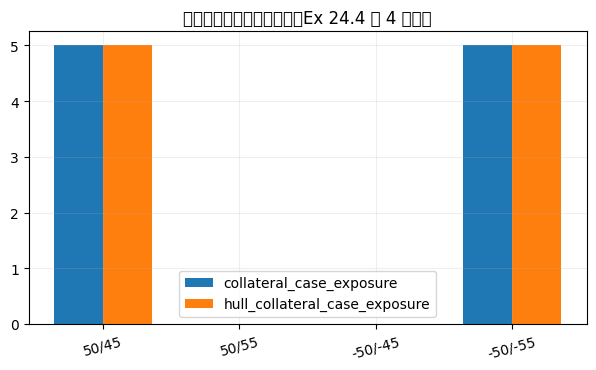

In [17]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("担保付きエクスポージャ：Ex 24.4 の 4 ケース")
x = np.arange(len(data["collateral_case_label"]))
ax.bar(x - .18, data["collateral_case_exposure"], width=.36, label="collateral_case_exposure")
ax.bar(x + .18, data["hull_collateral_case_exposure"], width=.36, label="hull_collateral_case_exposure")
ax.set_xticks(x, data["collateral_case_label"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Artifact恒等式の再計算検証

acceptance identityをcommitted artifactから直接recomputeし、JSONのフラグに依存せず主要な数値恒等式を確認する。

In [18]:
m = manifest['metrics']
spread_bp = data['cds_payoff_pv'].sum() / (data['cds_payment_pv'].sum() + data['cds_accrual_pv'].sum()) * 1e4
assert abs(spread_bp - 123.0) <= 0.5 and abs(spread_bp - m['cds_par_spread_bp']) <= 1e-9
times = data['tranche_payment_time']; prev = np.concatenate([[0.0], times[:-1]]); w = data['factor_weight']
E = data['tranche_expected_principal']; dt = times - prev; r = m['cdo_rate']
loss = E[:, :-1] - E[:, 1:]
A = w @ (dt * E[:, 1:] * np.exp(-r * times)).sum(axis=1)
B = w @ (0.5 * dt * loss * np.exp(-r * 0.5 * (times + prev))).sum(axis=1)
C = w @ (loss * np.exp(-r * 0.5 * (times + prev))).sum(axis=1)
assert abs(C / (A + B) * 1e4 - 348.0) <= 1.0
widths = data['capital_structure_detach'] - data['capital_structure_attach']
assert abs(widths @ data['capital_structure_expected_loss'] - m['portfolio_expected_loss']) <= 1e-8
assert np.all(np.diff(data['kth_spread']) < 0)
slopes = np.diff(data['el_curve_value']) / np.diff(data['el_curve_x'])
assert np.all(np.diff(data['el_curve_value']) > 0) and np.all(np.diff(slopes) < 0)
assert np.max(np.abs(data['compound_correlation'] - data['hull_compound_correlation'])) <= 0.01
assert np.max(np.abs(data['base_correlation'] - data['hull_base_correlation'])) <= 0.01
assert np.allclose(data['collateral_case_exposure'], [5, 0, 0, 5])
print('PASS: 123bp / 348bp / 153bp / Table 25.8 / loss conservation / Ex 24.4 recomputed from the artifact')

PASS: 123bp / 348bp / 153bp / Table 25.8 / loss conservation / Ex 24.4 recomputed from the artifact


## 練習問題

1. Table 25.2–25.4 の設定で支払いを四半期にしたとき、パースプレッドはどちらへ動くか。`cds_payment_pv` の構造から予想し、理由をアクルーアルの扱いで説明せよ。
2. `cds_mtm_seller` の傾きは何に等しいか。150bp の MTM 0.0111 と D=4.1150 から確かめよ。
3. Table 25.7 の列 F=−1.0104 で E_20 が 0.5648 まで落ちる理由を、条件付きデフォルト確率 Q(t|F) の式で説明せよ。
4. `tranche_spread_vs_rho` でエクイティのスプレッドが ρ とともに下がり、シニアが上がるのはなぜか。`capital_structure_expected_loss` の合計が ρ に依存しないことと整合させよ。
5. Table 25.8 でコンパウンド相関はスマイル、ベース相関はスキューになる。ガウシアンコピュラが市場と整合しているなら両者はどうなるはずか。`el_curve_value` の傾き ΔEL/ΔX が単調減少することはどの無裁定条件に対応するか。

## Gate判定

artifact fingerprint、finite values、主要identityを機械的に確認する。

In [19]:
assert all(np.all(np.isfinite(values)) for values in artifact_data.values() if values.dtype.kind in 'fiu')
assert manifest['companions'][artifact.name] == hashlib.sha256(artifact.read_bytes()).hexdigest()
assert set(manifest['companion_schemas'][artifact.name]) == set(artifact_data)
print('PASS: fingerprint, schema, units, and finite-value checks')

PASS: fingerprint, schema, units, and finite-value checks


## 限界とnegative results

本巻の数値はsynthetic fixtureによる教育・integration検証であり、市場予測力、収益性、実運用較正を示さない。複雑モデルがbaselineに勝たない場合もnegative resultとして保持する。

## Research track

未査読preprintや重いモデルはoptional profileに隔離し、core artifact・notebook・book・portalの再構築を妨げない。

## 参考文献

Hull (2022) Options, Futures, and Other Derivatives 11e, Ch.24–25; Vasicek (2002); Li (2000); Andersen, Sidenius & Basu (2003); Hull & White (2004); Hull & White (2003) CDS options.

## まとめ

価格・統計誤差だけでなく、hard constraints、下流risk、計算量、data/model limitationsを同じ成果物に固定した。